In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import time
import psutil
import os
from datetime import datetime
import csv
from IPython.display import display

In [2]:
print("\nLOADING DATA")
print("-"*40)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Load data
df = pd.read_csv("movies_cleaned.csv")

# Convert numeric columns
numeric_cols = ['budget', 'revenue', 'vote_average', 'vote_count', 'popularity', 'runtime']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

# Store metrics for summary
load_time = execution_time
load_memory = memory_delta
load_end_memory = end_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.2f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Rows loaded: {len(df):,}")
print(f"Columns: {len(df.columns)}")

df.head(5)


LOADING DATA
----------------------------------------

 BENCHMARKS:
Time: 8.88 seconds
Memory delta: 2380.02 MB
Memory total: 2536.28 MB
CPU: 0.0%
Rows loaded: 590,202
Columns: 166


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,director_count,main_director,has_director,good_director_data,missing_writers,has_multiple_writers,writers_count,main_writer,has_writers,good_writers_data
0,2,Ariel,7.1,367,Released,1988-10-21,0,73,0,tt0094675,...,1,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True
1,3,Shadows in Paradise,7.3,430,Released,1986-10-17,0,74,0,tt0092149,...,1,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True
2,5,Four Rooms,5.9,2780,Released,1995-12-09,4257354,98,4000000,tt0113101,...,4,Alexandre Rockwell,True,True,False,True,4,Allison Anders,True,True
3,6,Judgment Night,6.5,360,Released,1993-10-15,12136938,109,21000000,tt0107286,...,1,Stephen Hopkins,True,True,False,True,2,Lewis Colick,True,True
4,9,Sunday in August,6.8,28,Released,2004-09-02,0,15,0,tt0425473,...,1,Marc Meyer,True,True,False,False,1,Marc Meyer,True,True


In [3]:
print("\n" + "="*80)
print("ANALYSIS 1: ROI PER MOVIE")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# ROI = (revenue - budget) / budget (only when budget is greater than 0)
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")

df["roi"] = np.where(
    df["budget"] > 0,
    (df["revenue"] - df["budget"]) / df["budget"],
    np.nan
)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_processed = len(df)

# Store metrics for summary
analysis1_time = execution_time
analysis1_memory = memory_delta

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Rows processed: {rows_processed:,}")
print(f"ROI values calculated: {df['roi'].notna().sum():,}")

df[["id", "title", "year", "revenue", "budget", "roi"]].head()


ANALYSIS 1: ROI PER MOVIE

 BENCHMARKS:
Time: 0.0896 seconds
Memory delta: -122.88 MB
Memory total: 2413.84 MB
CPU: 0.0%
Rows processed: 590,202
ROI values calculated: 56,486


,id,title,year,revenue,budget,roi
0,2,Ariel,1988,0,0,NaN
1,3,Shadows in Paradise,1986,0,0,NaN
2,5,Four Rooms,1995,4257354,4000000,0.064339
3,6,Judgment Night,1993,12136938,21000000,-0.422051
4,9,Sunday in August,2004,0,0,NaN


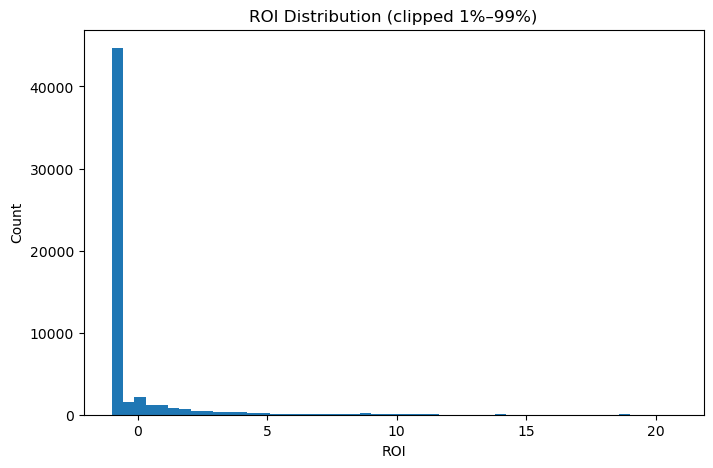

In [4]:
roi_vals = df["roi"].dropna()
roi_clip = roi_vals[roi_vals.between(roi_vals.quantile(0.01), roi_vals.quantile(0.99))]

plt.figure(figsize=(8,5))
plt.hist(roi_clip, bins=50)
plt.title("ROI Distribution (clipped 1%–99%)")
plt.xlabel("ROI")
plt.ylabel("Count")
plt.show()

In [5]:
print("\n" + "="*80)
print("ANALYSIS 2: AVERAGE ROI BY GENRE AND YEAR")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Ensuring that the year exists
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

df_genres = df.copy()

# Cleaning and splitting the genres column
df_genres["genres"] = df_genres["genres"].fillna("").astype(str)
df_genres["genre"] = df_genres["genres"].str.split(",")

# Exploding multi-genre rows
df_genres = df_genres.explode("genre")

# Cleaning genre values
df_genres["genre"] = df_genres["genre"].str.strip()
df_genres = df_genres[df_genres["genre"] != ""]

# Grouping by year and genre
avg_roi_by_genre_year = (
    df_genres
        .groupby(["year", "genre"], as_index=False)
        .agg(
            avg_roi=("roi", "mean"),
            movie_count=("id", "count")
        )
        .sort_values(["year", "avg_roi"], ascending=[True, False])
)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_processed = len(avg_roi_by_genre_year)
rows_per_second = rows_processed / execution_time if execution_time > 0 else 0

# Store metrics for summary
analysis2_time = execution_time
analysis2_memory = memory_delta

print(f"Total groups: {rows_processed:,}")
print(avg_roi_by_genre_year.head(20))
print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Groups created: {rows_processed:,}")
print(f"Groups/second: {rows_per_second:,.0f}")
print(f"Unique years: {avg_roi_by_genre_year['year'].nunique()}")
print(f"Unique genres: {avg_roi_by_genre_year['genre'].nunique()}")


ANALYSIS 2: AVERAGE ROI BY GENRE AND YEAR
Total groups: 2,433
    year        genre  avg_roi  movie_count
0   1888  Documentary      NaN            2
1   1890  Documentary      NaN            2
2   1891  Documentary      NaN            1
3   1892  Documentary      NaN            1
4   1893  Documentary      NaN            2
5   1893        Drama      NaN            2
6   1894       Action      NaN            2
7   1894       Comedy      NaN            3
8   1894        Crime      NaN            1
9   1894  Documentary      NaN           18
10  1894        Music      NaN            1
11  1894      Romance      NaN            1
12  1894      Western      NaN            4
13  1895       Comedy      NaN            4
14  1895  Documentary      NaN           22
15  1895        Drama      NaN            1
16  1895       Family      NaN            1
17  1895      History      NaN            1
18  1896       Action      NaN            1
19  1896    Animation      NaN            1

 BENCHMARKS:

In [6]:
avg_roi_by_genre_year[avg_roi_by_genre_year["avg_roi"].notna()].head(20)

,year,genre,avg_roi,movie_count
85,1902,Adventure,-1.000,3
91,1902,Fantasy,-1.000,8
95,1902,Science Fiction,-1.000,1
96,1903,Action,-1.000,3
97,1903,Adventure,-1.000,2
99,1903,Crime,-1.000,4
108,1903,Western,-1.000,1
110,1904,Adventure,-1.000,1
111,1904,Comedy,-1.000,14
115,1904,Fantasy,-1.000,12


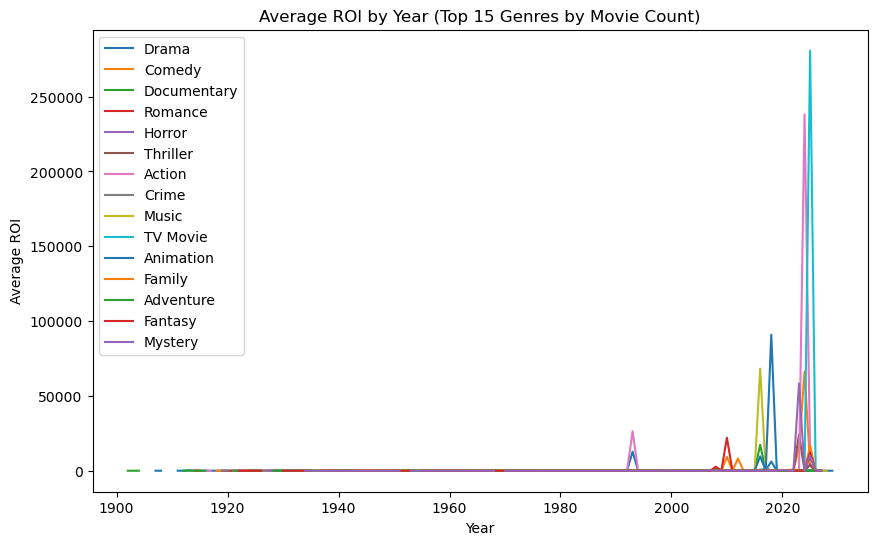

In [7]:
# Top 15 genres by total movie count
top_genres = (
    avg_roi_by_genre_year.groupby("genre")["movie_count"].sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

plt.figure(figsize=(10,6))
for g in top_genres:
    tmp = avg_roi_by_genre_year[avg_roi_by_genre_year["genre"] == g].sort_values("year")
    plt.plot(tmp["year"], tmp["avg_roi"], label=g)

plt.title("Average ROI by Year (Top 15 Genres by Movie Count)")
plt.xlabel("Year")
plt.ylabel("Average ROI")
plt.legend()
plt.show()

In [8]:
print("\n" + "="*80)
print("ANALYSIS 3: PROFITABILITY THRESHOLD FILTER (ROI > 2)")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

high_roi_movies = df[df["roi"] > 2].copy()
high_roi_movies = high_roi_movies.sort_values("roi", ascending=False)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_processed = len(high_roi_movies)

# Store metrics for summary
analysis3_time = execution_time
analysis3_memory = memory_delta

print(f"Total movies with ROI > 2: {rows_processed:,}")
display(high_roi_movies[["id", "title", "year", "revenue", "budget", "roi"]].head(20))
print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Filtered rows: {rows_processed:,}")
print(f"Max ROI: {high_roi_movies['roi'].max():,.0f}")


ANALYSIS 3: PROFITABILITY THRESHOLD FILTER (ROI > 2)
Total movies with ROI > 2: 4,307


,id,title,year,revenue,budget,roi
499985,1300939,Verguizas Cabronas,2024,100000000,1,1.000000e+08
459654,1175807,Honk,2023,100000000,5,2.000000e+07
482845,1248416,Ginger Person,2024,10000000,1,9.999999e+06
547552,1468122,The NeedyMonster,2025,800000000,150,5.333332e+06
556306,1500094,Starters: Rare Candy,2018,20000000,4,4.999999e+06
125554,270650,Oy Vey! My Son Is Gay!,2010,6000007,2,3.000002e+06
66572,114903,Between Us,2012,2755584,1,2.755583e+06
185694,391698,The Beatles: Eight Days a Week - The Touring Y...,2016,12283800,5,2.456759e+06
41097,65299,The Judas Project,1993,2850135,2,1.425066e+06
556301,1500071,Starters - Typomaniac,2016,1000000,2,4.999990e+05



 BENCHMARKS:
Time: 0.0314 seconds
Memory delta: 162.36 MB
Memory total: 3017.39 MB
CPU: 0.0%
Filtered rows: 4,307
Max ROI: 99,999,999


In [9]:
print("\n" + "="*80)
print("ANALYSIS 4: REVENUE VS BUDGET CORRELATION BY DECADE")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Ensuring that year exists
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

# Creating the decade column (e.g., 1994 -> 1990)
df["decade"] = (df["year"] // 10) * 10

# Keeping valid financial rows for correlation
df_corr = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

corr_by_decade = (
    df_corr
        .groupby("decade")[["revenue", "budget"]]
        .corr()
        .iloc[::2, -1]  # selects revenue-budget correlation
        .reset_index(name="revenue_budget_corr")
        .sort_values("decade")
)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_processed = len(corr_by_decade)

# Store metrics for summary
analysis4_time = execution_time
analysis4_memory = memory_delta

print(f"Total decades analyzed: {rows_processed}")
display(corr_by_decade)
print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Decades analyzed: {rows_processed}")
print(f"Unique decades: {corr_by_decade['decade'].nunique()}")
print(f"Correlation range: {corr_by_decade['revenue_budget_corr'].min():.4f} - {corr_by_decade['revenue_budget_corr'].max():.4f}")


ANALYSIS 4: REVENUE VS BUDGET CORRELATION BY DECADE
Total decades analyzed: 12


,decade,level_1,revenue_budget_corr
0,1910,revenue,0.160273
1,1920,revenue,0.235385
2,1930,revenue,0.295073
3,1940,revenue,0.097854
4,1950,revenue,0.515112
5,1960,revenue,0.292447
6,1970,revenue,0.343887
7,1980,revenue,0.366689
8,1990,revenue,0.576564
9,2000,revenue,0.734652



 BENCHMARKS:
Time: 0.0580 seconds
Memory delta: 12.62 MB
Memory total: 3030.31 MB
CPU: 0.0%
Decades analyzed: 12
Unique decades: 12
Correlation range: 0.0979 - 0.8075


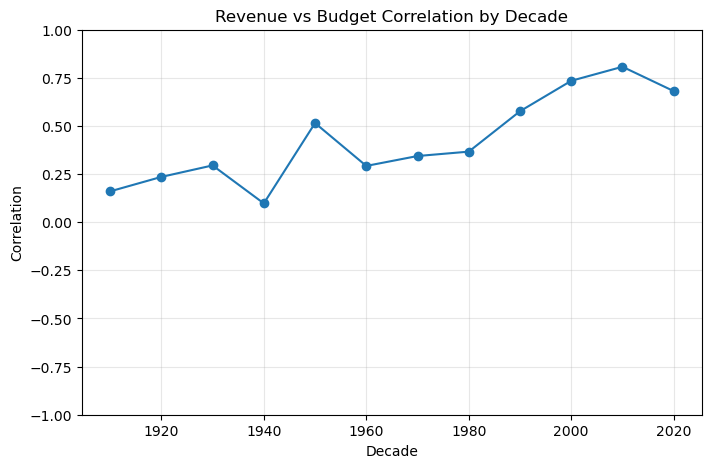

In [10]:
plt.figure(figsize=(8,5))
plt.plot(corr_by_decade["decade"], corr_by_decade["revenue_budget_corr"], marker='o')
plt.title("Revenue vs Budget Correlation by Decade")
plt.xlabel("Decade")
plt.ylabel("Correlation")
plt.ylim(-1, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
print("\n" + "="*80)
print("ANALYSIS 5: TOP 10 MOST PROFITABLE MOVIES PER YEAR")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Ensuring year exists
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

# Ensuring ROI exists
if "roi" not in df.columns:
    raise ValueError("ROI column not found. Run Q1 (ROI per Movie) first.")

# Keeping only valid ROI rows
df_profit = df[df["roi"].notna()].copy()

# Sorting and selecting Top 10 per year by ROI
top10_profitable_per_year = (
    df_profit
        .sort_values(["year", "roi"], ascending=[True, False])
        .groupby("year")
        .head(10)
        [["year", "id", "title", "revenue", "budget", "roi"]]
)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_processed = len(top10_profitable_per_year)
rows_per_second = rows_processed / execution_time if execution_time > 0 else 0

# Store metrics for summary
analysis5_time = execution_time
analysis5_memory = memory_delta

print(f"Total rows in top 10 per year: {rows_processed:,}")
display(top10_profitable_per_year.head(30))
print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Unique years with data: {top10_profitable_per_year['year'].nunique()}")
print(f"Average movies per year: {rows_processed / top10_profitable_per_year['year'].nunique():.1f}")


ANALYSIS 5: TOP 10 MOST PROFITABLE MOVIES PER YEAR
Total rows in top 10 per year: 1,114


,year,id,title,revenue,budget,roi
608,1902,775,A Trip to the Moon,0,5985,-1.000000
3112,1903,5698,The Great Train Robbery,0,150,-1.000000
1905,1904,2963,The Impossible Voyage,0,10000,-1.000000
57962,1905,94643,Rescued by Rover,0,37,-1.000000
65930,1907,113260,Ben Hur,0,500,-1.000000
73692,1908,132394,The Adventures of Dollie,0,1000,-1.000000
461054,1911,1180455,"Water, Klimaat en Film",1,500,-0.998000
205722,1911,434136,Infidelity,0,2231,-1.000000
390487,1911,943338,The Fatal Wedding,0,800,-1.000000
404205,1911,988601,"Captain Midnight, the Bush King",0,987,-1.000000



 BENCHMARKS:
Time: 0.1602 seconds
Memory delta: 90.34 MB
Memory total: 3121.08 MB
CPU: 0.0%
Unique years with data: 125
Average movies per year: 8.9


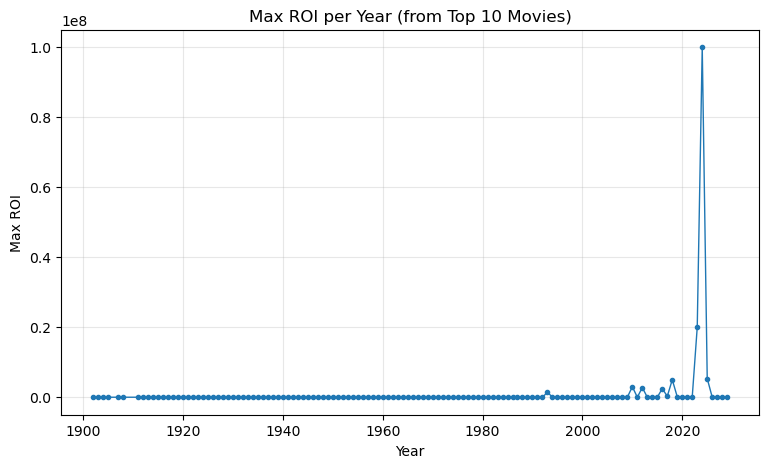

In [12]:
yearly_max_roi = (
    top10_profitable_per_year.groupby("year")["roi"].max().dropna()
)

plt.figure(figsize=(9,5))
plt.plot(yearly_max_roi.index, yearly_max_roi.values, marker='o', markersize=3, linestyle='-', linewidth=1)
plt.title("Max ROI per Year (from Top 10 Movies)")
plt.xlabel("Year")
plt.ylabel("Max ROI")
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
print("\n" + "="*80)
print("ANALYSIS 6: BUDGET DISTRIBUTION STATISTICS")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Making budget numeric
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")

# Keeping only valid budgets (> 0)
df_budget = df[df["budget"] > 0].copy()

budget_stats = pd.Series({
    "count": f"{df_budget['budget'].count():,}",
    "mean": f"${df_budget['budget'].mean():,.2f}",
    "std_dev": f"${df_budget['budget'].std():,.2f}",
    "variance": f"${df_budget['budget'].var():,.2f}",
    "min": f"${df_budget['budget'].min():,.2f}",
    "max": f"${df_budget['budget'].max():,.2f}",
    "median": f"${df_budget['budget'].median():,.2f}",
    "25th percentile": f"${df_budget['budget'].quantile(0.25):,.2f}",
    "75th percentile": f"${df_budget['budget'].quantile(0.75):,.2f}"
})

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_processed = len(df_budget)

# Store metrics for summary
analysis6_time = execution_time
analysis6_memory = memory_delta

print(f"Movies with valid budget (>0): {rows_processed:,}")
display(budget_stats)
print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Valid budget entries: {rows_processed:,}")
print(f"Percentage of total: {rows_processed/len(df)*100:.1f}%")


ANALYSIS 6: BUDGET DISTRIBUTION STATISTICS
Movies with valid budget (>0): 56,486


count                               56,486
mean                         $5,593,675.87
std_dev                     $20,106,203.80
variance           $404,259,431,220,311.38
min                                  $1.00
max                        $583,900,000.00
median                          $15,000.00
25th percentile                    $650.00
75th percentile              $1,500,000.00
dtype: object


 BENCHMARKS:
Time: 0.0957 seconds
Memory delta: 41.69 MB
Memory total: 3163.30 MB
CPU: 0.0%
Valid budget entries: 56,486
Percentage of total: 9.6%


In [14]:
print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)

# Collect results from all analyses
results = [
    {"Analysis": "Data Loading", "Time (s)": load_time if 'load_time' in locals() else 0, 
     "Memory (MB)": load_memory if 'load_memory' in locals() else 0},
    
    {"Analysis": "ROI per Movie", "Time (s)": analysis1_time if 'analysis1_time' in locals() else 0, 
     "Memory (MB)": analysis1_memory if 'analysis1_memory' in locals() else 0},
    
    {"Analysis": "ROI by Genre & Year", "Time (s)": analysis2_time if 'analysis2_time' in locals() else 0, 
     "Memory (MB)": analysis2_memory if 'analysis2_memory' in locals() else 0},
    
    {"Analysis": "Profitability Filter", "Time (s)": analysis3_time if 'analysis3_time' in locals() else 0, 
     "Memory (MB)": analysis3_memory if 'analysis3_memory' in locals() else 0},
    
    {"Analysis": "Correlation by Decade", "Time (s)": analysis4_time if 'analysis4_time' in locals() else 0, 
     "Memory (MB)": analysis4_memory if 'analysis4_memory' in locals() else 0},
    
    {"Analysis": "Top 10 per Year", "Time (s)": analysis5_time if 'analysis5_time' in locals() else 0, 
     "Memory (MB)": analysis5_memory if 'analysis5_memory' in locals() else 0},
    
    {"Analysis": "Budget Statistics", "Time (s)": analysis6_time if 'analysis6_time' in locals() else 0, 
     "Memory (MB)": analysis6_memory if 'analysis6_memory' in locals() else 0}
]

# Create DataFrame for better display
summary_df = pd.DataFrame(results)

# Calculate totals
total_time = summary_df["Time (s)"].sum()
total_memory = summary_df["Memory (MB)"].sum()

print("\n" + "-"*60)
print(f"{'Analysis':<35} {'Time (s)':<12} {'Memory (MB)':<12}")
print("-"*60)

for _, row in summary_df.iterrows():
    print(f"{row['Analysis']:<35} {row['Time (s)']:<12.2f} {row['Memory (MB)']:<12.2f}")

print("-"*60)
print(f"{'TOTAL':<35} {total_time:<12.2f} {total_memory:<12.2f}")
print("-"*60)

# Additional insights
print("\n" + "="*60)
print("INSIGHTS")
print("="*60)
if total_time > 0:
    max_time_idx = summary_df['Time (s)'].idxmax()
    max_memory_idx = summary_df['Memory (MB)'].idxmax()
    print(f"• Most time-consuming: {summary_df.loc[max_time_idx, 'Analysis']} ({summary_df['Time (s)'].max():.2f}s)")
    print(f"• Most memory-intensive: {summary_df.loc[max_memory_idx, 'Analysis']} ({summary_df['Memory (MB)'].max():.2f}MB)")
    print(f"• Average time per analysis: {total_time/len(results):.2f}s")
print(f"• Total dataset size: {len(df):,} rows" if 'df' in locals() else "• Total dataset size: N/A")
print(f"• Final memory usage: {psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024):.2f} MB")
print("="*80)


PERFORMANCE SUMMARY

------------------------------------------------------------
Analysis                            Time (s)     Memory (MB) 
------------------------------------------------------------
Data Loading                        8.88         2380.02     
ROI per Movie                       0.09         -122.88     
ROI by Genre & Year                 3.13         410.08      
Profitability Filter                0.03         162.36      
Correlation by Decade               0.06         12.62       
Top 10 per Year                     0.16         90.34       
Budget Statistics                   0.10         41.69       
------------------------------------------------------------
TOTAL                               12.45        2974.23     
------------------------------------------------------------

INSIGHTS
• Most time-consuming: Data Loading (8.88s)
• Most memory-intensive: Data Loading (2380.02MB)
• Average time per analysis: 1.78s
• Total dataset size: 590,202 rows
• 

Mapreduce Implementation - Qeury ROI be genre and year 

In [16]:
# ============================================================
# MAPREDUCE - ROI BY GENRE & YEAR
# ============================================================

from pyspark.sql import SparkSession
import time
import pandas as pd

# Start Spark 
try:
    spark
except NameError:
    spark = SparkSession.builder \
        .appName("ROI_MapReduce") \
        .master("local[*]") \
        .getOrCreate()

sc = spark.sparkContext

start_time = time.time()

# Make sure year exists
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

# Clean genres into lists
df_mr = df[["genres", "year", "revenue", "budget"]].copy()
df_mr["genres"] = df_mr["genres"].fillna("").astype(str).str.split(",")
df_mr["genres"] = df_mr["genres"].apply(lambda x: [g.strip() for g in x if g.strip() != ""])

# Convert to records
records = df_mr.to_dict("records")
rdd = sc.parallelize(records)

def compute_roi(row):
    budget = row["budget"]
    revenue = row["revenue"]
    if pd.notna(budget) and pd.notna(revenue) and budget > 0:
        return (revenue - budget) / budget
    return None

result = (
    rdd.flatMap(lambda row: [
        ((genre, row["year"]), (compute_roi(row), 1))
        for genre in row["genres"]
        if row["year"] is not None and compute_roi(row) is not None
    ])
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    .map(lambda x: (x[0][0], x[0][1], x[1][0] / x[1][1], x[1][1]))
)

df_roi_mr = pd.DataFrame(
    result.collect(),
    columns=["genre", "year", "avg_roi", "movie_count"]
).sort_values(["year", "avg_roi"], ascending=[True, False])

end_time = time.time()

print("Top results:")
print(df_roi_mr.head(10))
print(f"\nTime: {end_time - start_time:.2f}s")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 12:35:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/19 12:35:44 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/19 12:35:44 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/19 12:35:46 WARN TaskSetManager: Stage 0 contains a task of very large size (2404 KiB). The maximum recommended task size is 1000 KiB.


Top results:
                genre  year  avg_roi  movie_count
413   Science Fiction  1902     -1.0            1
797         Adventure  1902     -1.0            1
1777          Fantasy  1902     -1.0            1
278            Action  1903     -1.0            1
448           Western  1903     -1.0            1
643         Adventure  1903     -1.0            1
1223            Crime  1903     -1.0            1
440   Science Fiction  1904     -1.0            1
636           Fantasy  1904     -1.0            1
1209        Adventure  1904     -1.0            1

Time: 3.29s
